# <span style="color:rgb(213,80,0)">This code creates a set of figures used in the paper:</span>

## Robust Multivariate Analysis with Missing Observations

# <span style="color:rgb(213,80,0)"> </span>

## Load the cows2026 dataset and display correlations

In [1]:


load cows2026
X2=cows2026{:,:};
disp('Correlation matrix with listwise deletion')

Correlation matrix with listwise deletion

In [2]:
R1=corr(X2,'Rows','complete');
disp(R1)

    1.0000    0.3763    0.4133    0.3640    0.2544    0.3591    0.3211
    0.3763    1.0000    0.4817    0.3517    0.2915    0.3648    0.3287
    0.4133    0.4817    1.0000    0.4029    0.3291    0.4207    0.3993
    0.3640    0.3517    0.4029    1.0000    0.2592    0.3468    0.3541
    0.2544    0.2915    0.3291    0.2592    1.0000    0.3295    0.4996
    0.3591    0.3648    0.4207    0.3468    0.3295    1.0000    0.4777
    0.3211    0.3287    0.3993    0.3541    0.4996    0.4777    1.0000

In [3]:
disp('Correlation matrix with pairwise deletion')

Correlation matrix with pairwise deletion

In [4]:
R2=corr(X2,'Rows','pairwise');
disp(R2)

    1.0000    0.3195    0.5590    0.3540    0.2373    0.4106    0.2941
    0.3195    1.0000    0.4570    0.3163    0.2491    0.2423    0.2362
    0.5590    0.4570    1.0000    0.2911    0.2680    0.3825    0.2980
    0.3540    0.3163    0.2911    1.0000    0.3038    0.2812    0.3884
    0.2373    0.2491    0.2680    0.3038    1.0000    0.2444    0.5095
    0.4106    0.2423    0.3825    0.2812    0.2444    1.0000    0.3813
    0.2941    0.2362    0.2980    0.3884    0.5095    0.3813    1.0000

In [5]:
prin=false;
[n,p]=size(X2);


[XcompleteCases,idxRemovedCows]=rmmissing(X2);


## EM TEM application: input data for index plot of MD

alpha = 0, (no trimming) creates Figure 4 and alpha = 0.5 creates Figure 5


In [6]:
alpha=0.5;


if alpha==0
    outEM = mdEM(X2);
else
    outEM = mdTEM(X2,'method','pri','alpha',alpha);
end
muHat = outEM.loc;
SigHat = outEM.cov;
[d2_part, poss] = mdPartialMD(X2, muHat, SigHat);
d2_pri =mdPartialMD2full(d2_part, p, poss, 'method','pri');


## Index plot of robust Mahalanobis distances (Figure 5)

In [7]:
malindexplot(d2_pri,p,'conflev',0.95,'numlab',{8})

ans = 14.0671


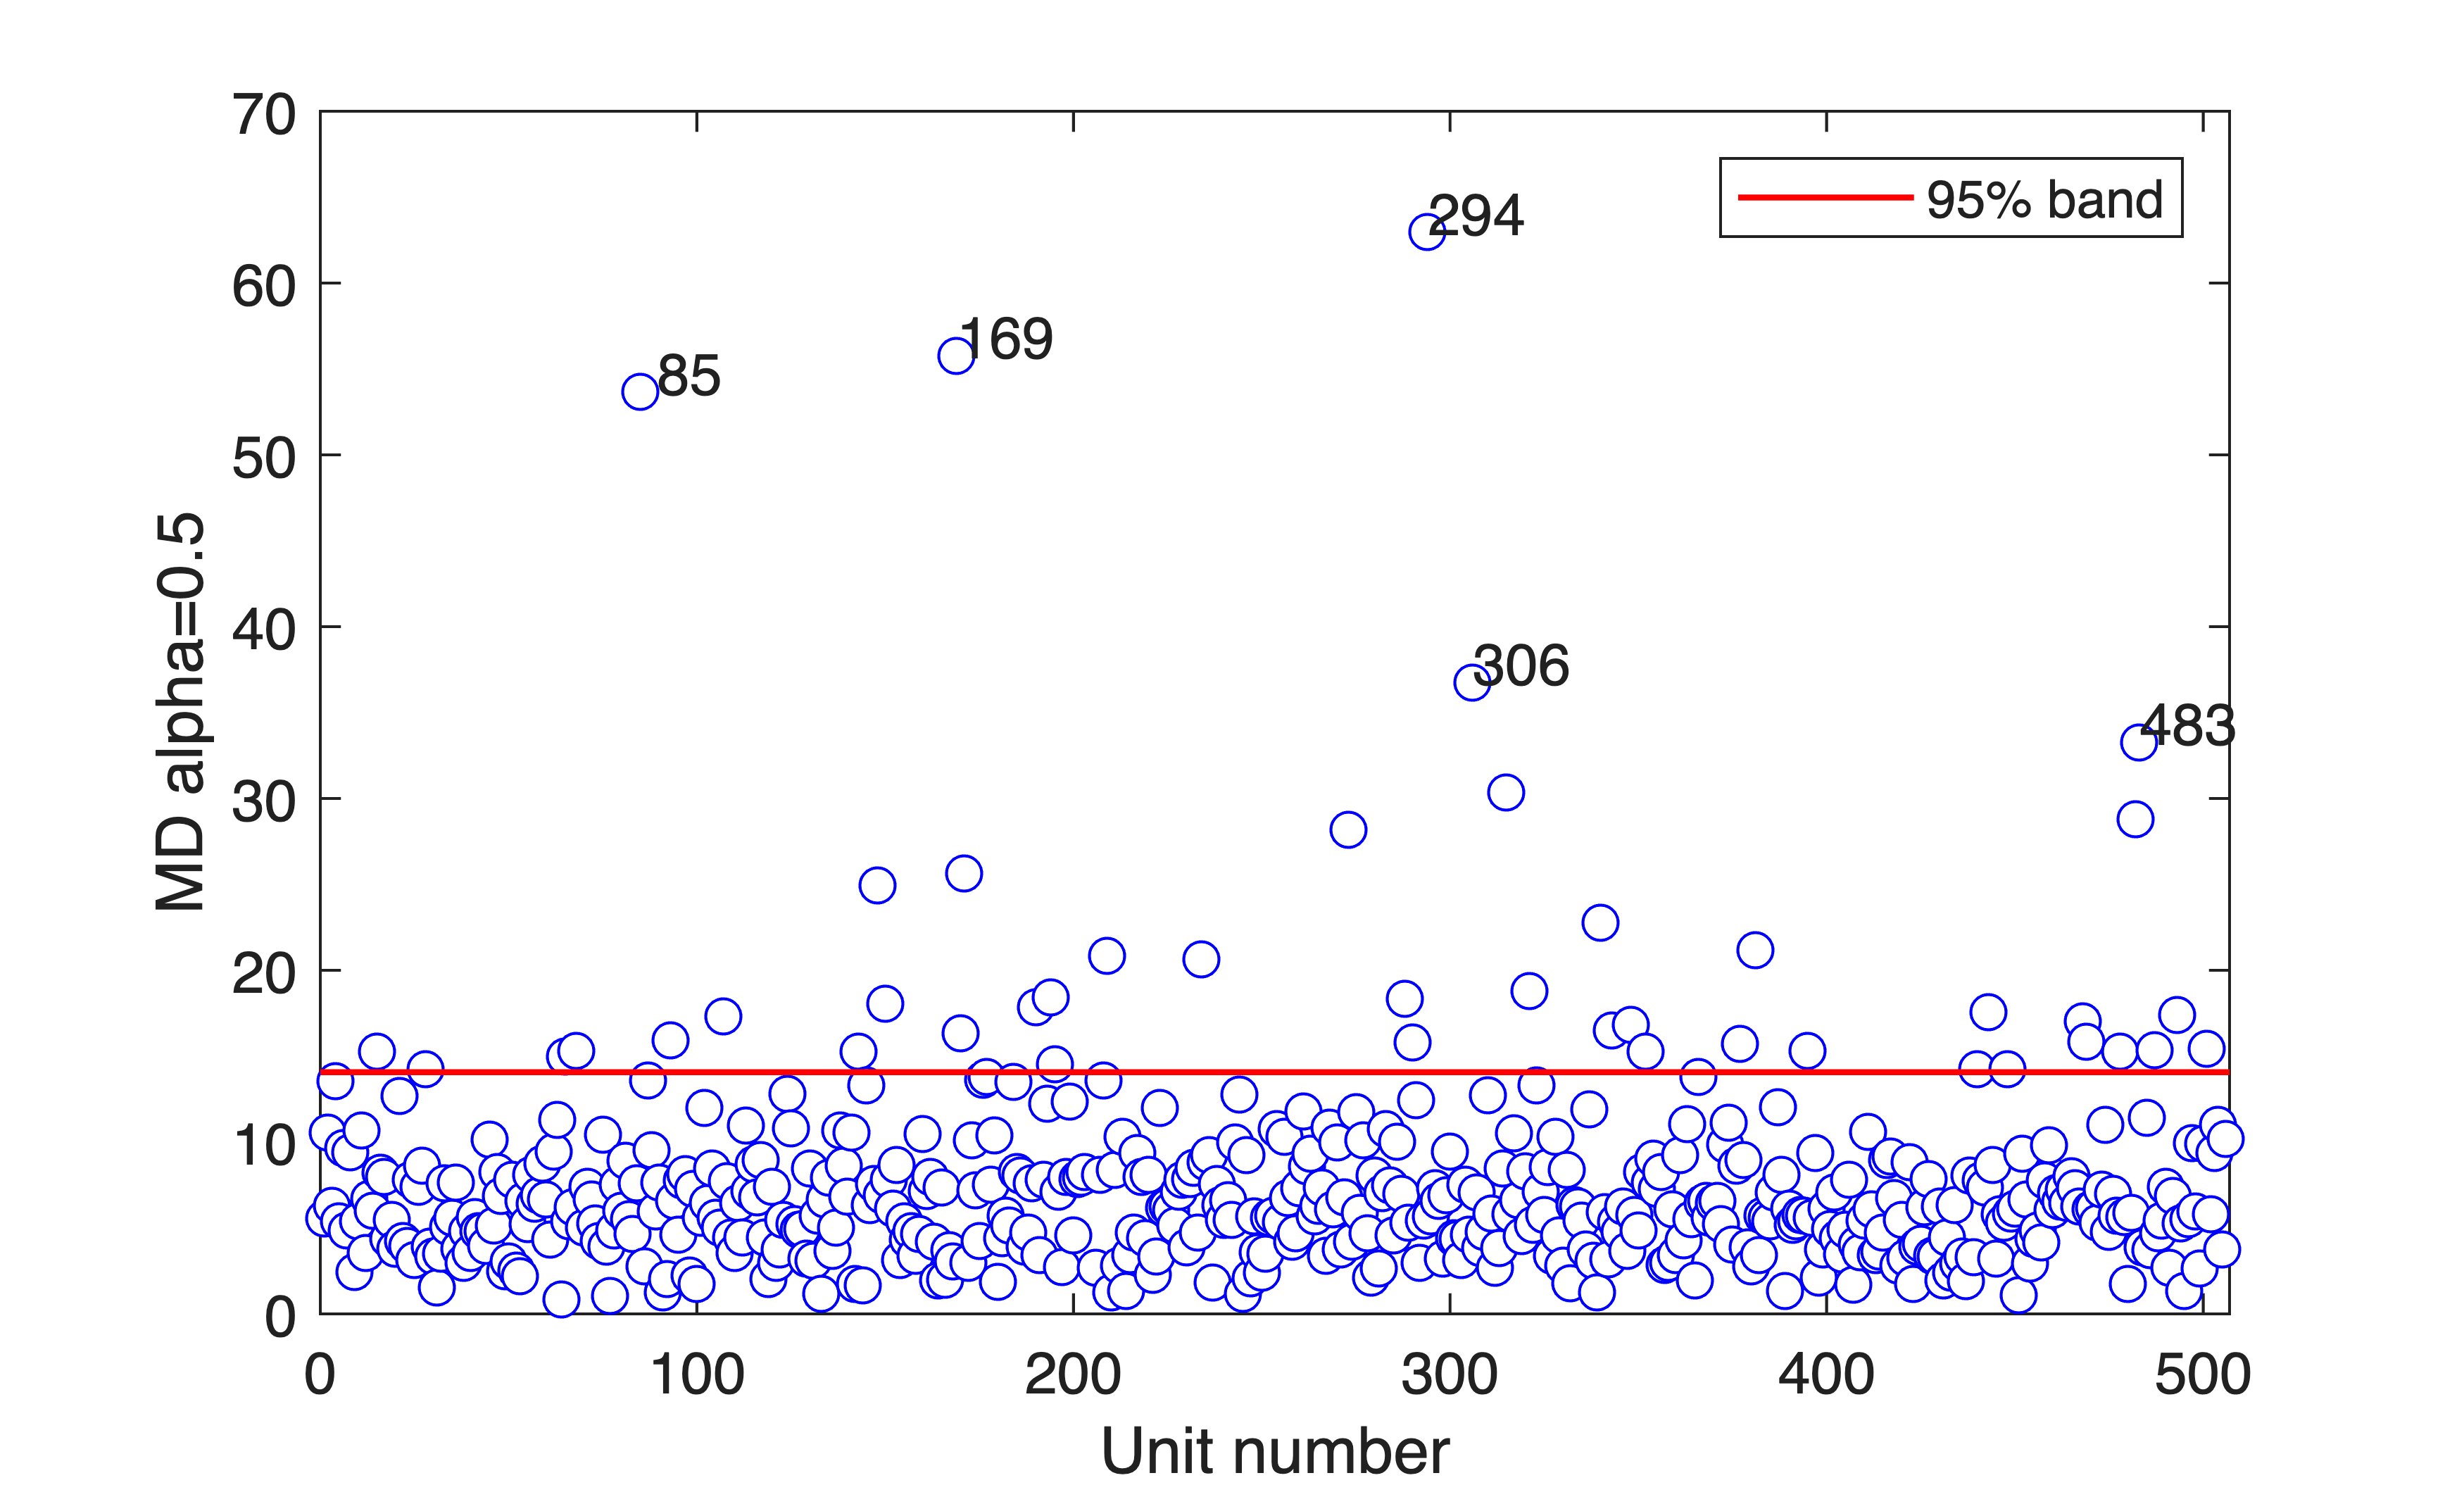

In [8]:
xlim([0 n+1])
title('')
ylabel(['MD alpha=' num2str(alpha)])
xlabel('Unit number')

In [9]:


if prin == true
    exportgraphics(gcf,'figs/MDindex050.pdf');
    % exportgraphics(gcf,'figs/MDindex000.pdf')
end


## Scatter plot matrix with outliers (Figure 6)


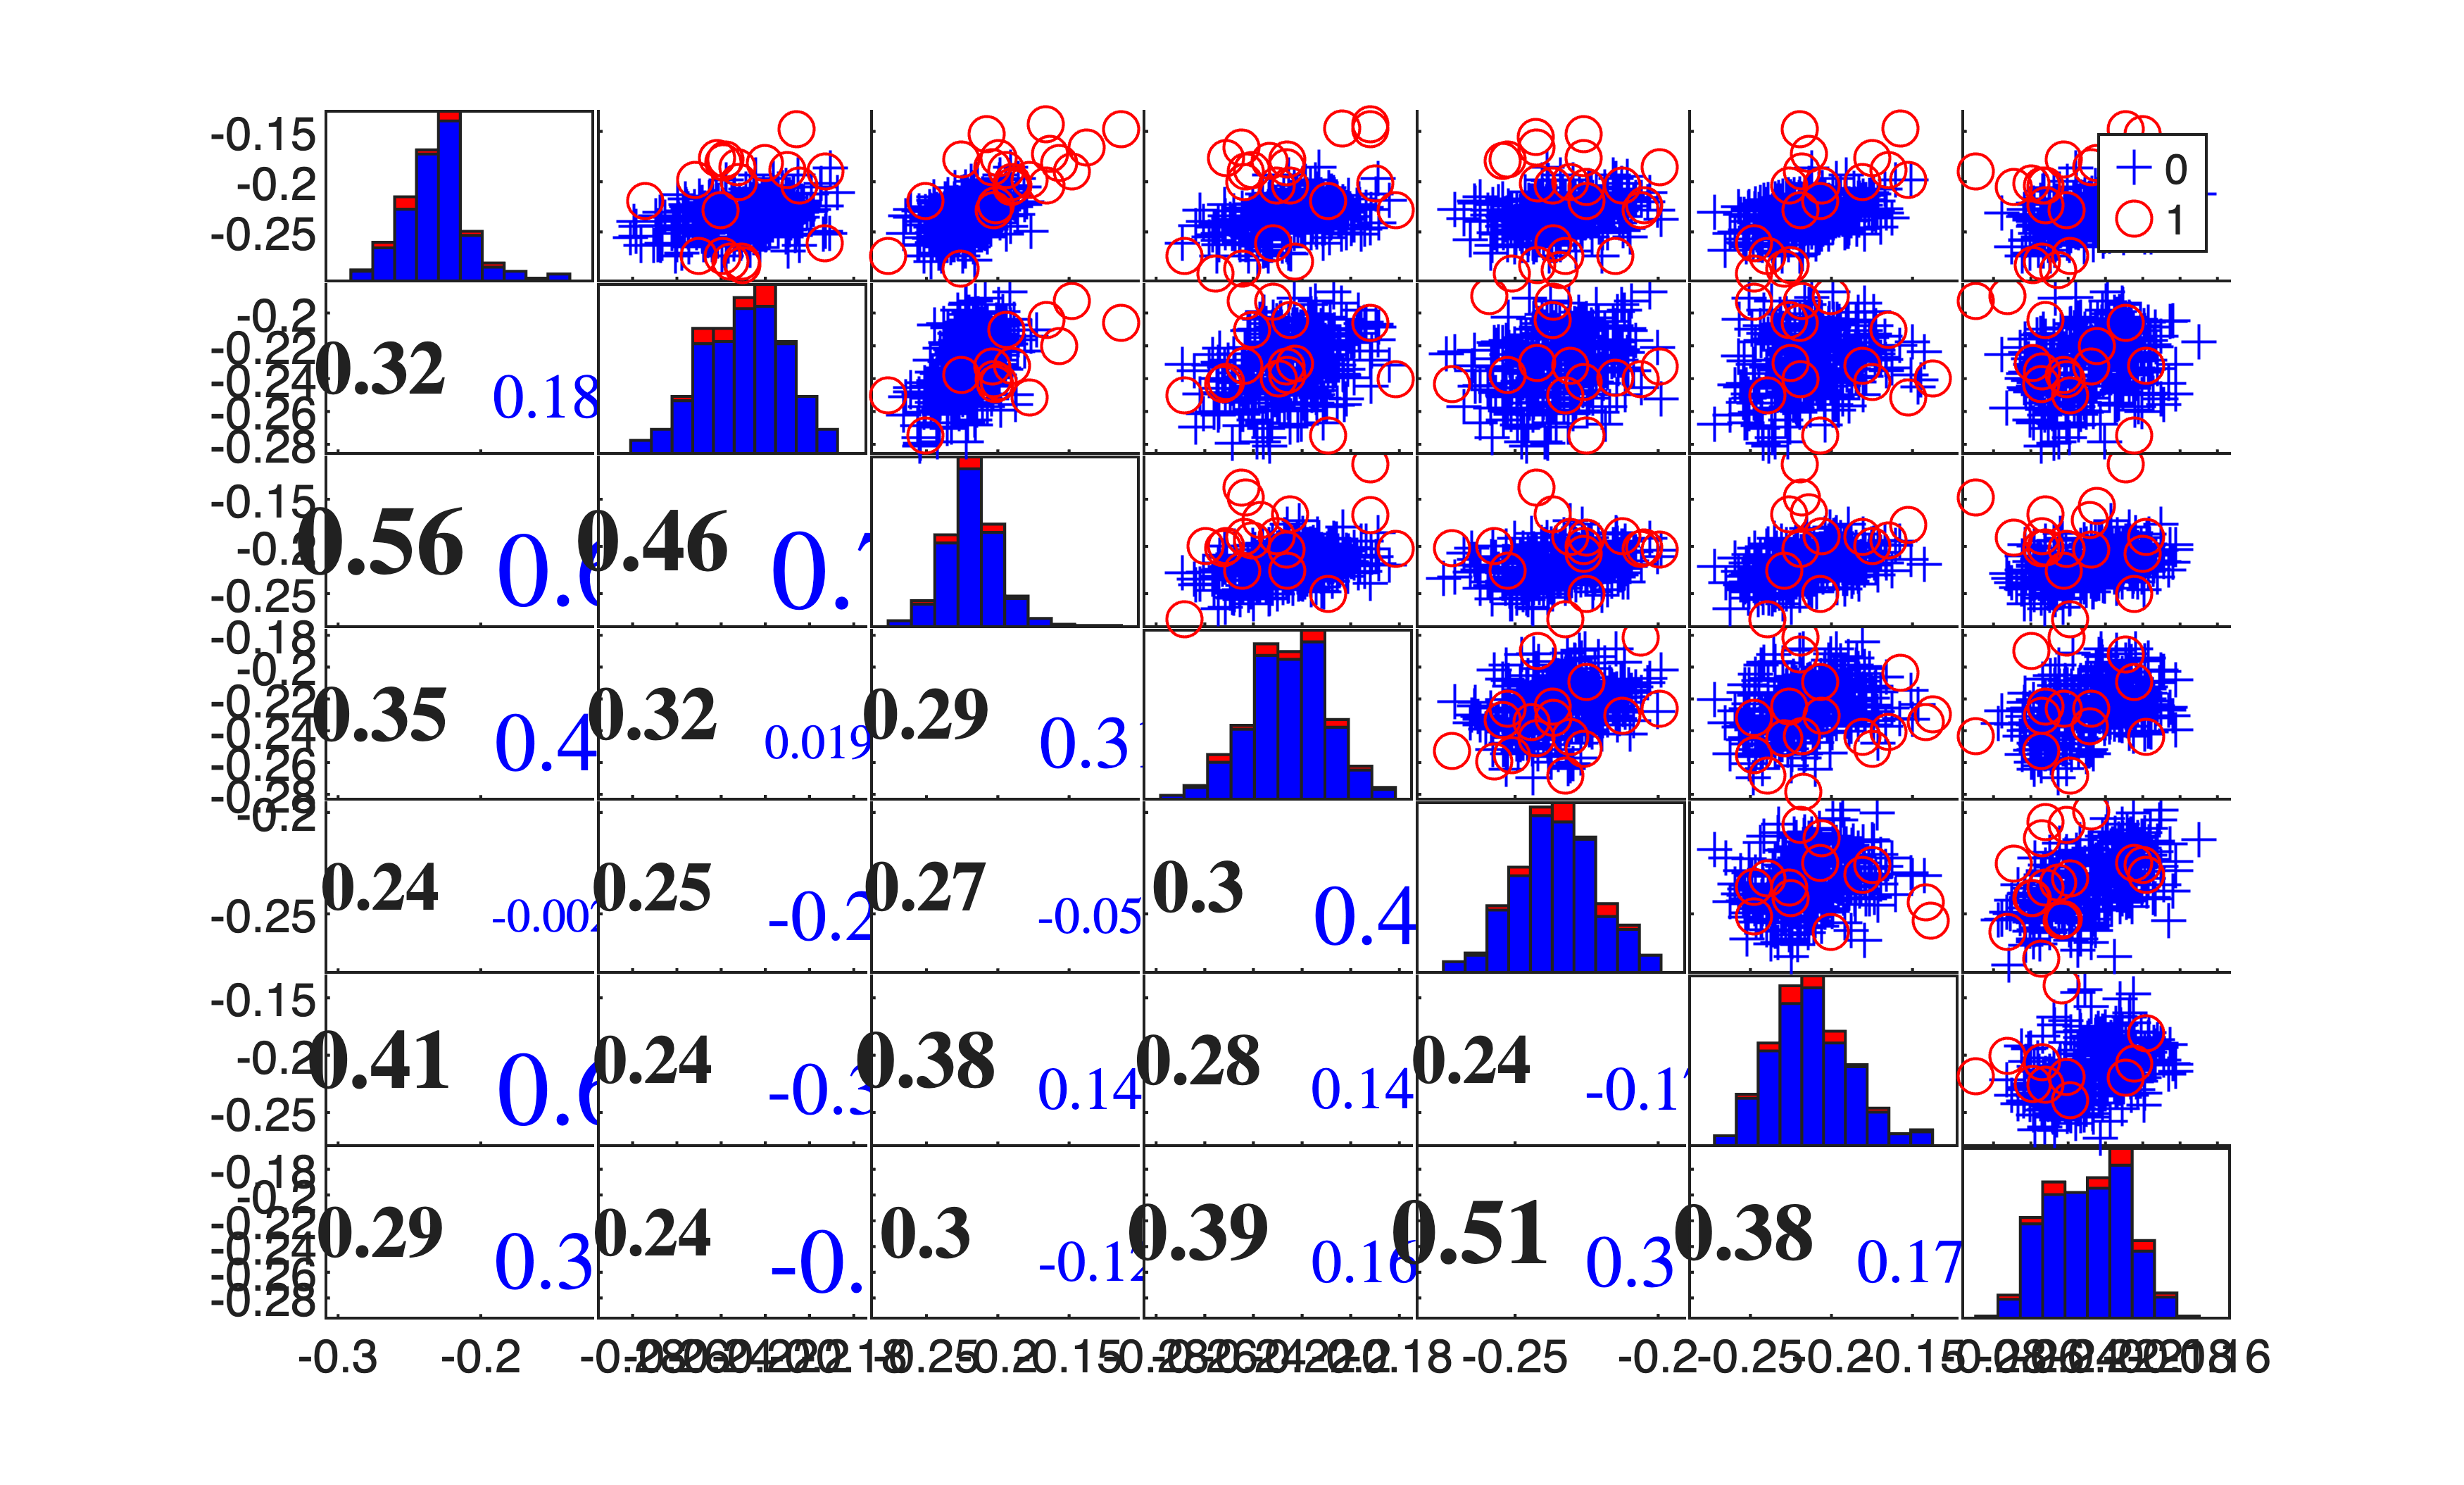

In [10]:
figure
bool=d2_pri>chi2inv(0.95,p);
typespm="upper";
spmplot(X2,"group",bool,"typespm",typespm);

In [11]:
disp('Number of units decleared as outliers')

Number of units decleared as outliers

In [12]:
disp(sum(bool))

    43

In [13]:


if prin == true
    exportgraphics(gcf,'figs/spmplot050.pdf');
end


## Compare original distances for complete rows before and after EM (Figure 8)


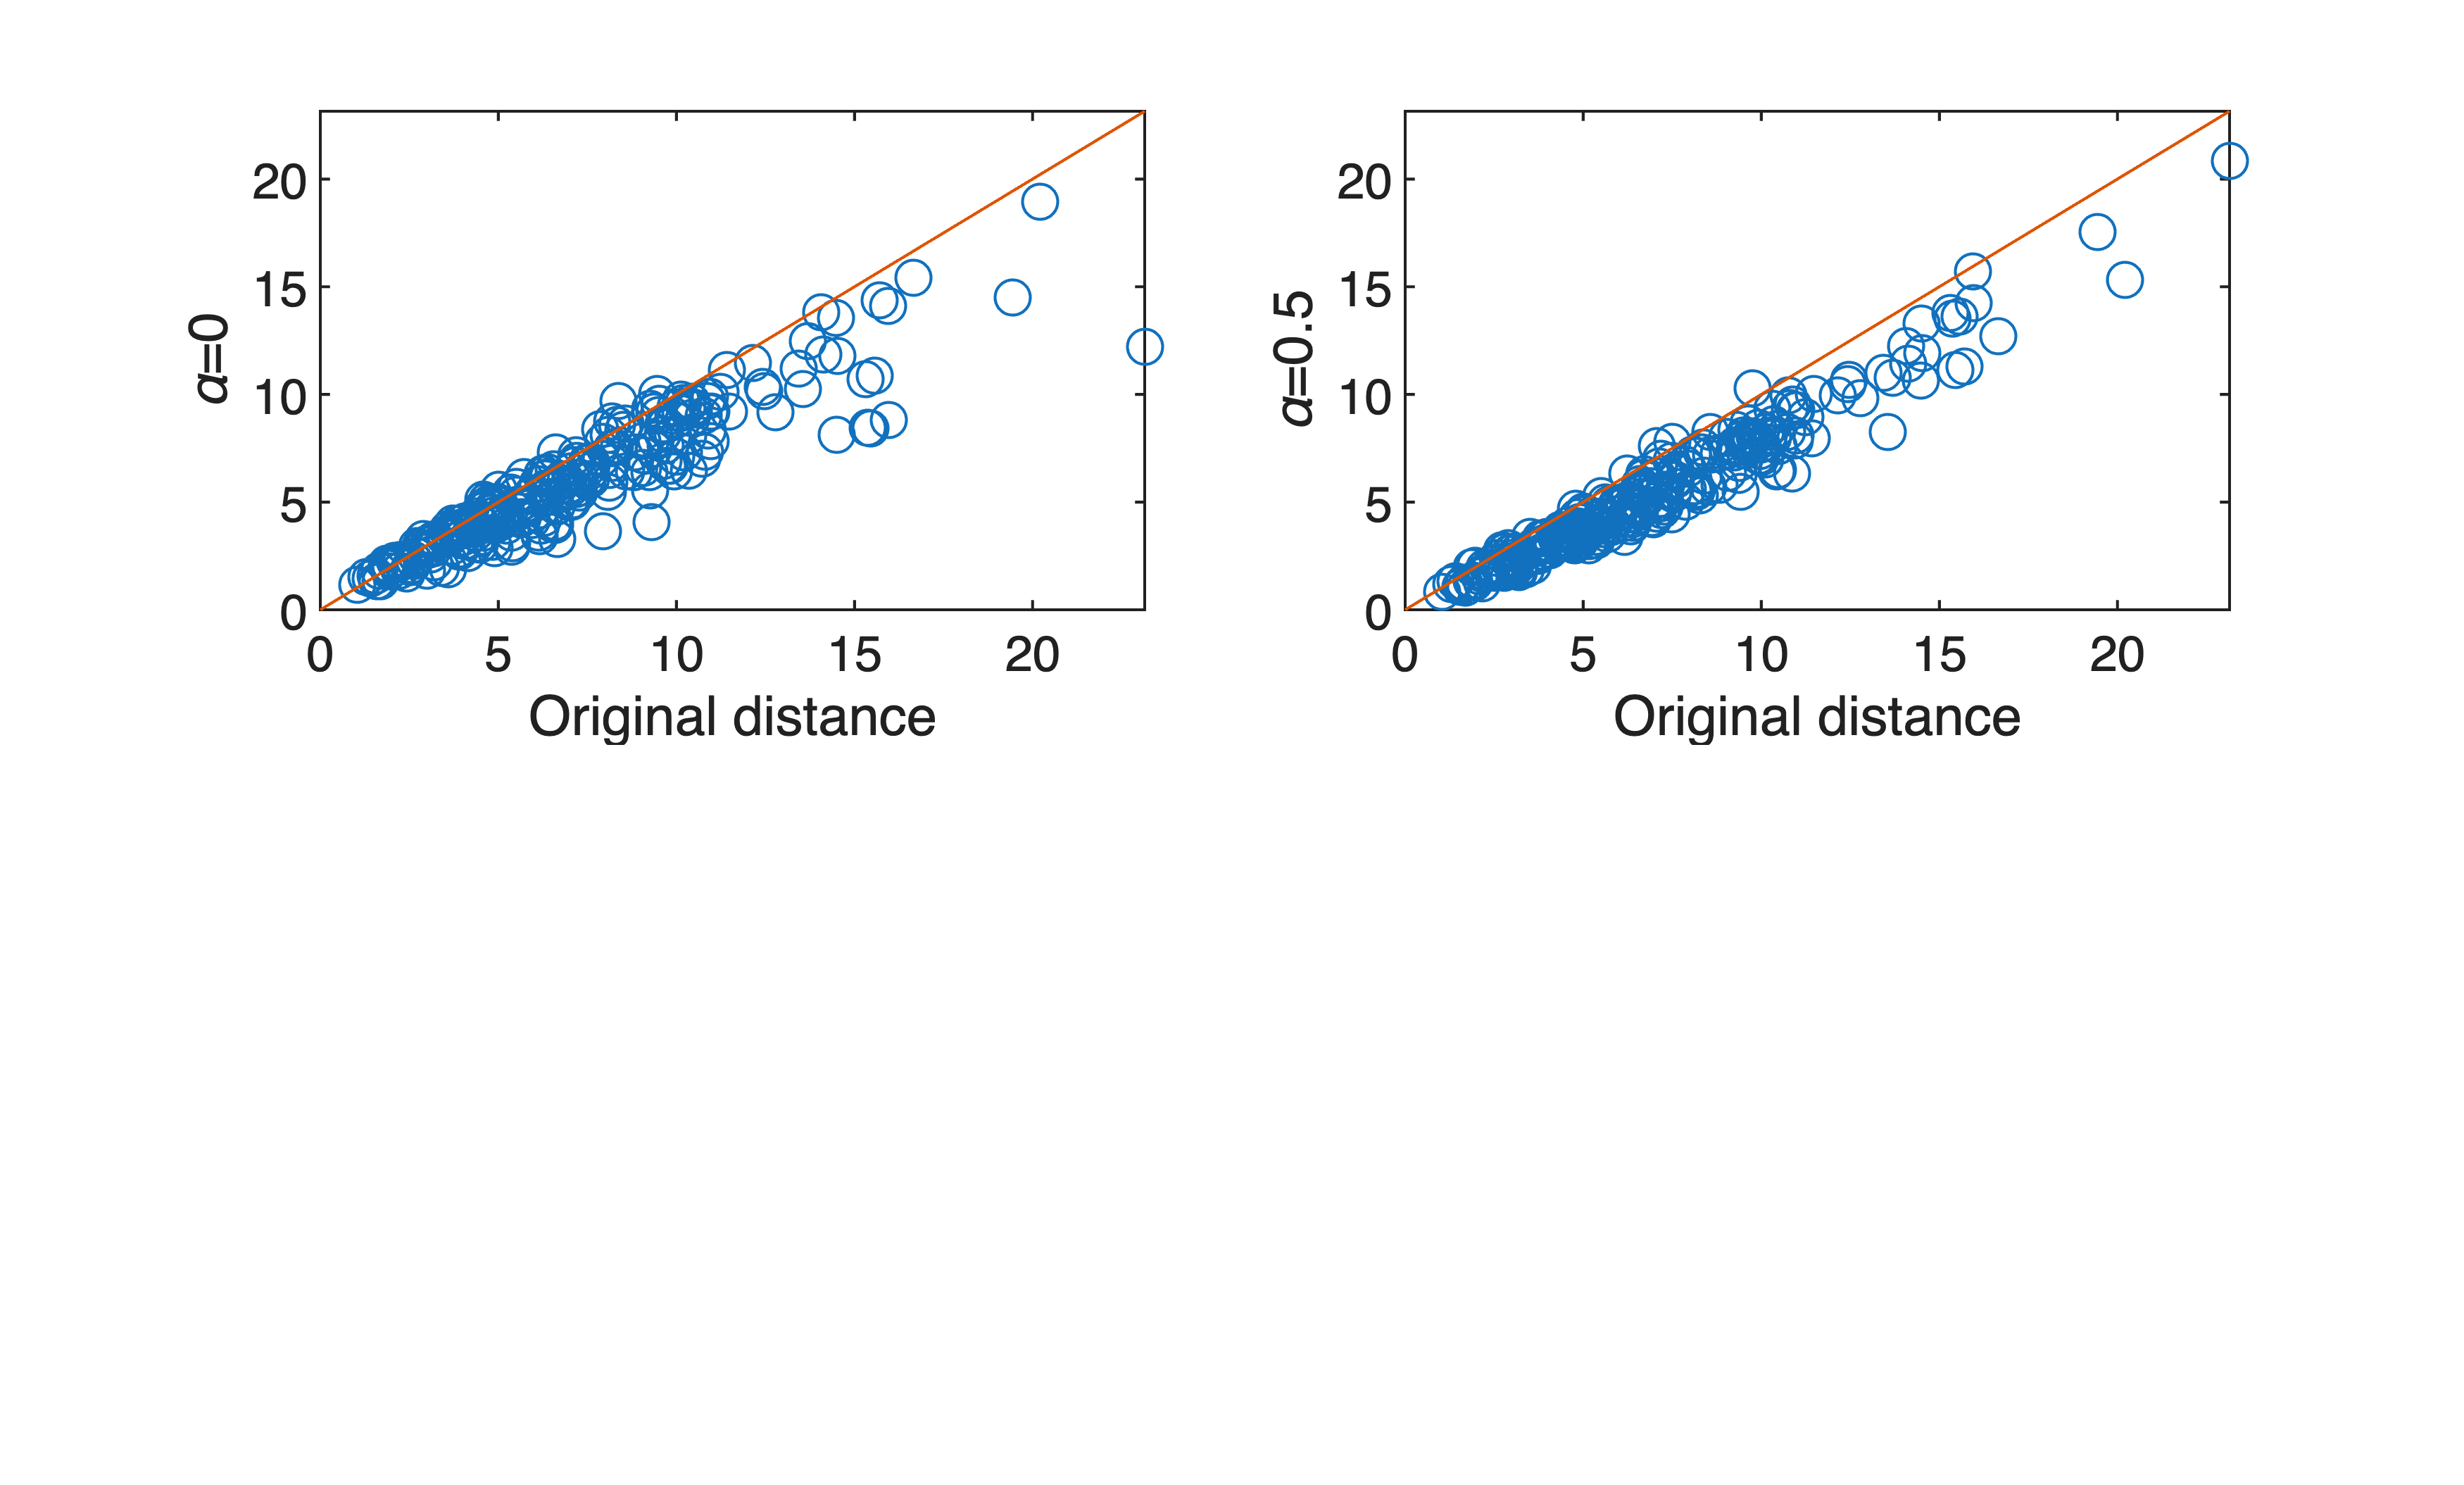

In [14]:
figure
d2OriCows=mahalFS(XcompleteCases,mean(XcompleteCases),cov(XcompleteCases));


Alpha=[0 0.5];
for j=1:2
    subplot(2,2,j)
    alpha=Alpha(j);


    if alpha==0
        outEM = mdEM(X2);
    else
        outEM = mdTEM(X2,'method','pri','alpha',alpha);
    end


    muHat = outEM.loc;
    SigHat = outEM.cov;
    [d2_part, poss] = mdPartialMD(X2, muHat, SigHat);


    d2_pri =mdPartialMD2full(d2_part, p, poss, 'method','pri');
    d2_priAUG=d2_pri;
    d2_priAUG(idxRemovedCows)=[];
    scatter(d2OriCows,d2_priAUG)
    refline(1)
    xlabel('Original distance')
    % ylabel('Distance from EM')
    ylabel(['\alpha=' num2str(alpha)])
    box on
end

In [15]:
if prin == true
    exportgraphics(gcf,'figs/testMCARcows.pdf');
end


## Number of outliers as function of level of trimming (Table 1)

In [16]:
tol=1e-10;
close all
Alpha=[0.5 0.25 0.20 0.15 0.10 0.05 0.01 0]';
methods=["pri" "betaMap"];
numout=zeros(length(Alpha),2);
for j=1:length(methods)
for i=1:length(Alpha)


    if Alpha(i)==0
        outEM = mdEM(X2);
    else
        outEM = mdTEM(X2,'method',methods(j),'alpha',Alpha(i),'tol',tol);
    end


    muHat = outEM.loc;
    SigHat = outEM.cov;
    [d2_part, poss] = mdPartialMD(X2, muHat, SigHat);


    d2_pri =mdPartialMD2full(d2_part, p, poss, 'method','pri');


    bool=d2_pri>chi2inv(0.95,p);
    numout(i,j)=sum(bool);
end
end


AlphaNout=array2table(numout,"RowNames",string(Alpha),"VariableNames",methods);
disp('Number of units above Chi2 0.95 threshold for different alpha with 2 rescaling methods')

Number of units above Chi2 0.95 threshold for different alpha with 2 rescaling methods

In [17]:
disp(AlphaNout)

            pri    betaMap
            ___    _______
    0.5     43       45   
    0.25    42       41   
    0.2     42       39   
    0.15    37       36   
    0.1     36       35   
    0.05    30       28   
    0.01    26       26   
    0       25       25

In [18]:
% If plot is needed uncomment what is below
%{
    plot(Alpha,numout)
    xlabel('Trimming level')
    ylabel('Number of units declared outliers')
    set(gca,"XDir","reverse")
    legend(methods)
%}


## Creation of Figure with 4 panels which compares original distances for

complete rows before and after EM (Figure 7)



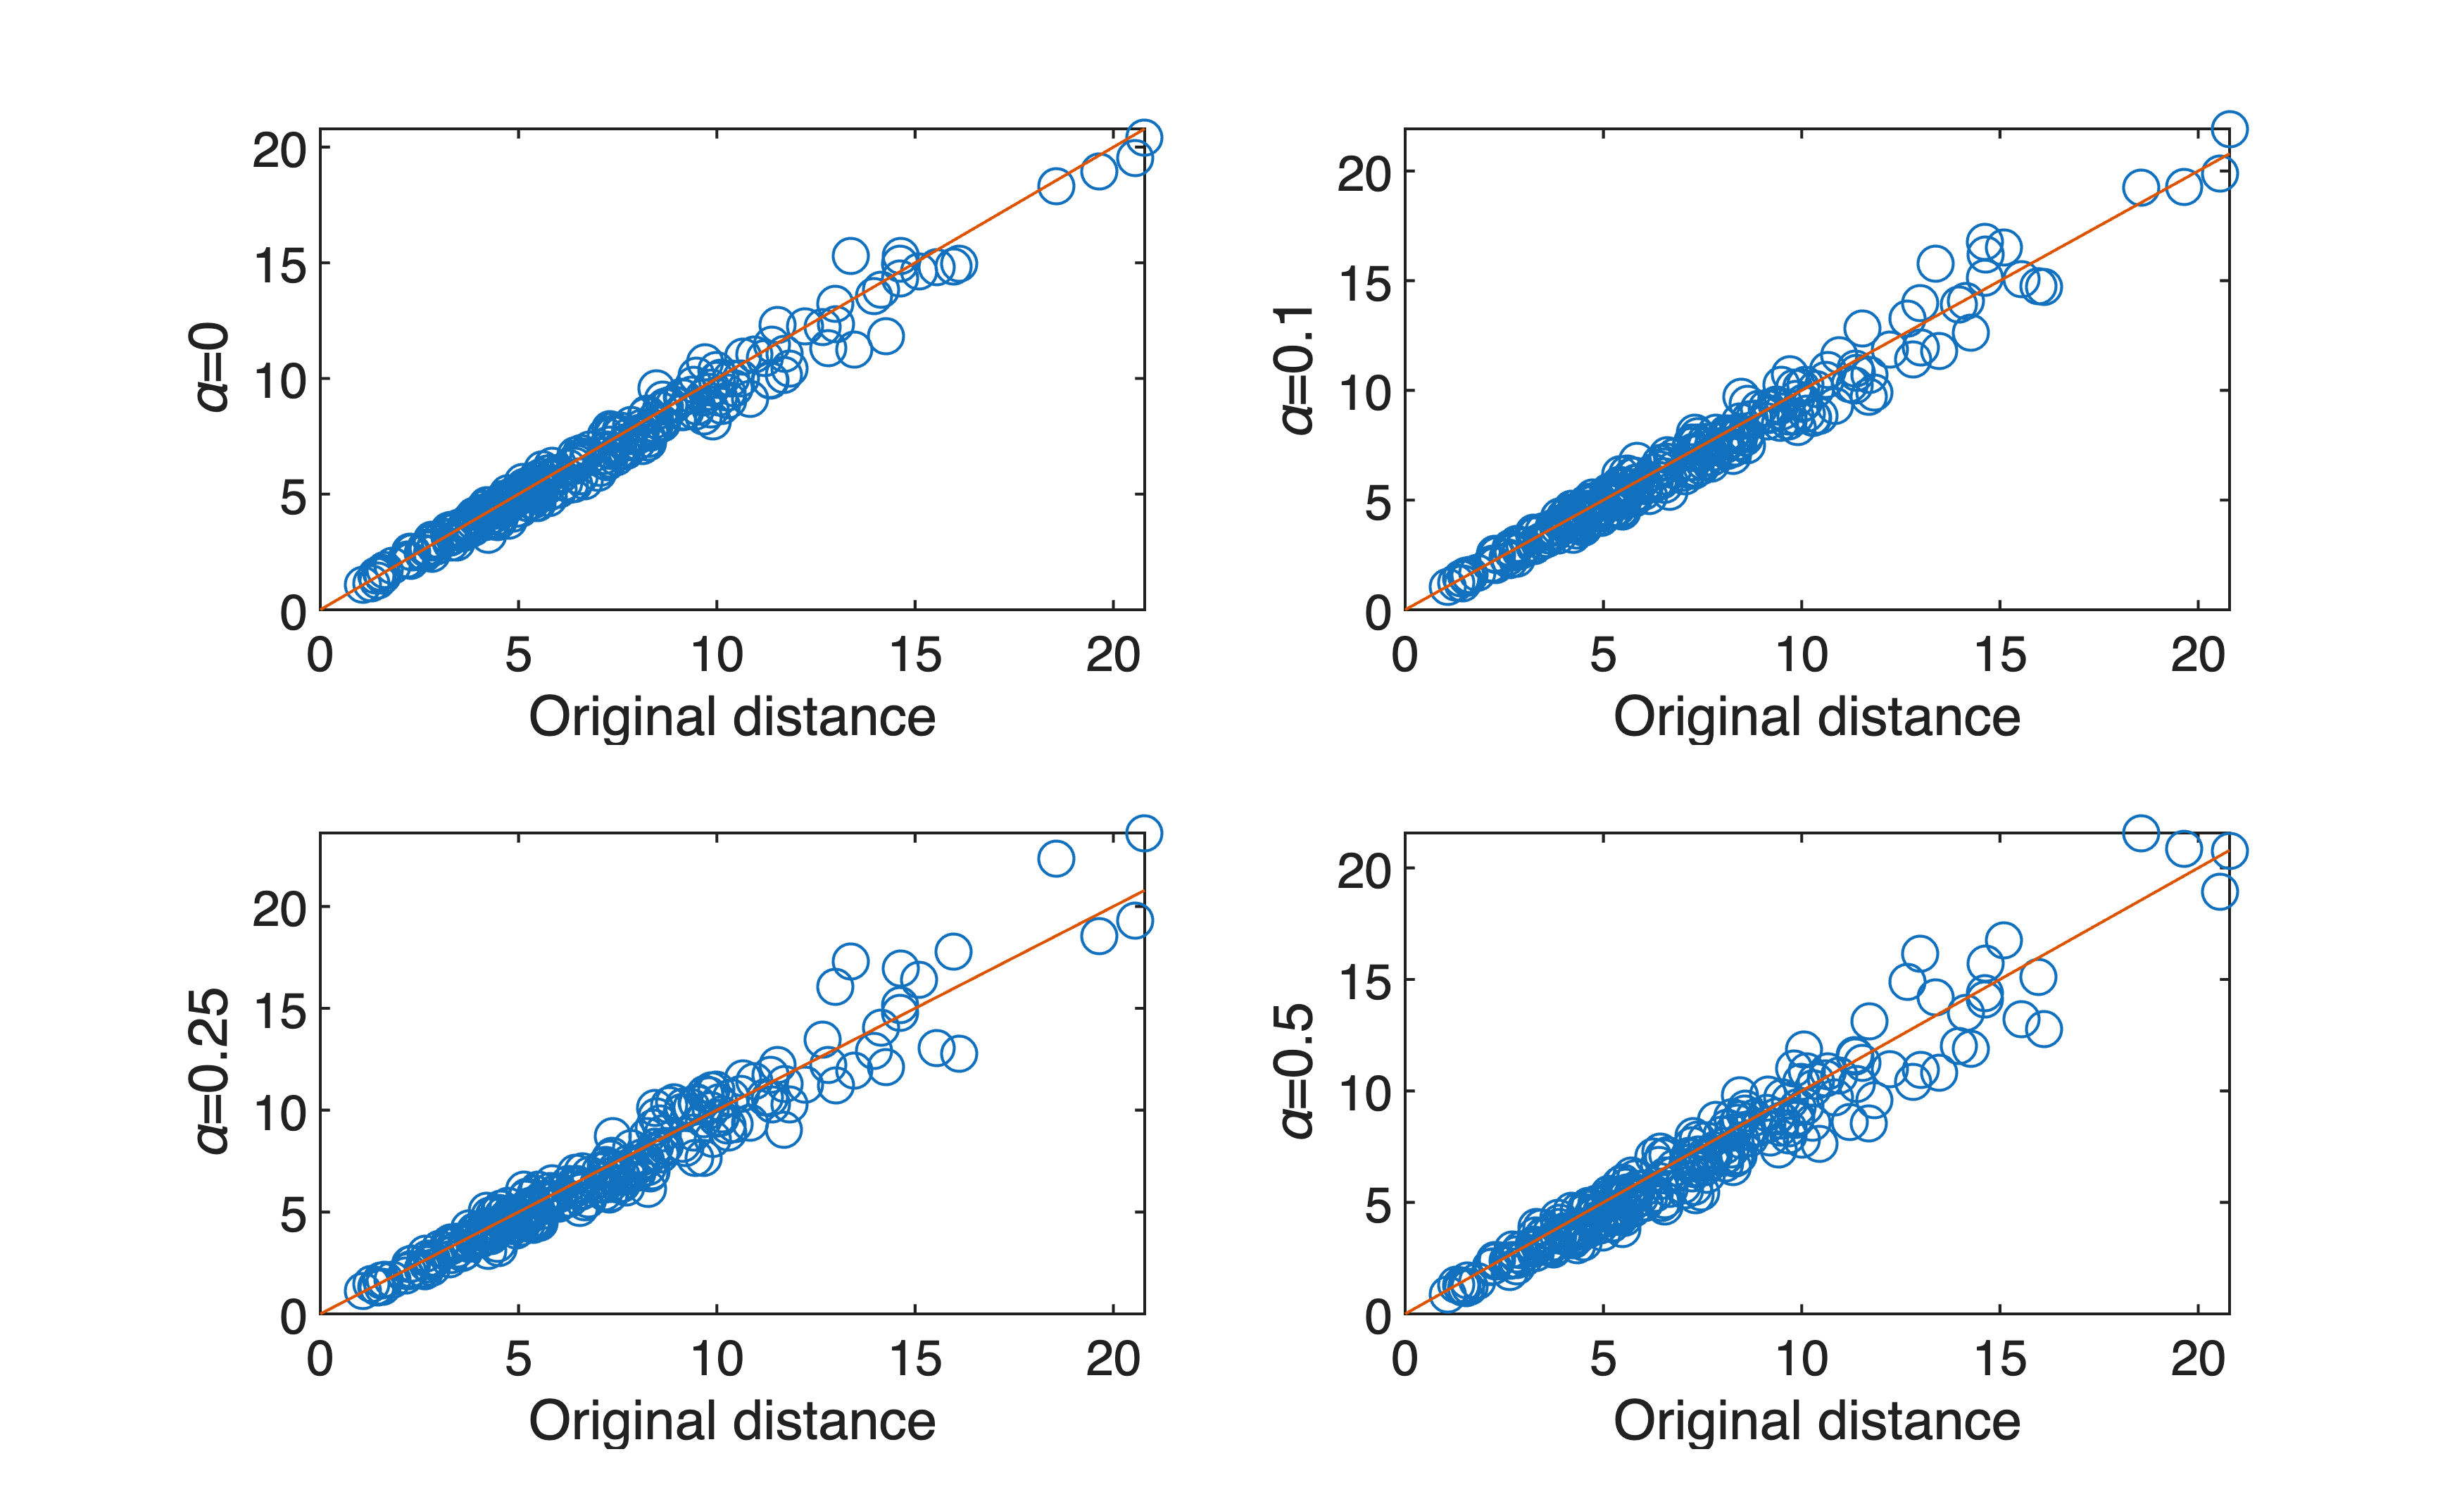

In [19]:
figure
rng(11)
p = 7;                % number of variables
n = 500;              % number of observations
rho = 0.5;            % target pairwise correlation (0<rho<1)
Sigma = (1-rho)*eye(p) + rho*ones(p);
R = chol(Sigma);      % upper-triangular such that Sigma = R'*R
missRate = 0.09;      % MCAR missing probability per entry


% Generate samples ~ N(0,Sigma)
Yfull = randn(n,p) * R;   % Strong positive correlation between the vars
missMask = rand(n,p) < missRate;
mu=mean(Yfull)';
S=cov(Yfull);
Y=Yfull;
Y(missMask) = NaN;
tol=1e-12;


[XcompleteCaseSIM,idxRemoved]=rmmissing(Y);
d2Ori=mahalFS(XcompleteCaseSIM,mean(XcompleteCaseSIM),cov(XcompleteCaseSIM));


figure
Alpha=[0 0.1 0.25 0.5];
for j=1:4
    subplot(2,2,j)
    alpha=Alpha(j);


    if alpha==0
        outEM = mdEM(Y);
    else
        outEM = mdTEM(Y,'method','pri','alpha',alpha);
    end


    muHat = outEM.loc;
    SigHat = outEM.cov;
    [d2_part, poss] = mdPartialMD(Y, muHat, SigHat);


    d2_pri =mdPartialMD2full(d2_part, p, poss, 'method','pri');


    d2_priAUG=d2_pri;
    d2_priAUG(idxRemoved)=[];
    scatter(d2Ori,d2_priAUG)
    refline(1)
    xlabel('Original distance')
    ylabel(['\alpha=' num2str(alpha)])
    box on
end

In [20]:


if prin == true
    exportgraphics(gcf,'figs/testMCAR.pdf')
end


## Call function which implements the test

To replicate exactly Figure 9, the parameter 'nsimul' of the function mdMCARtest() should be set to 10000.



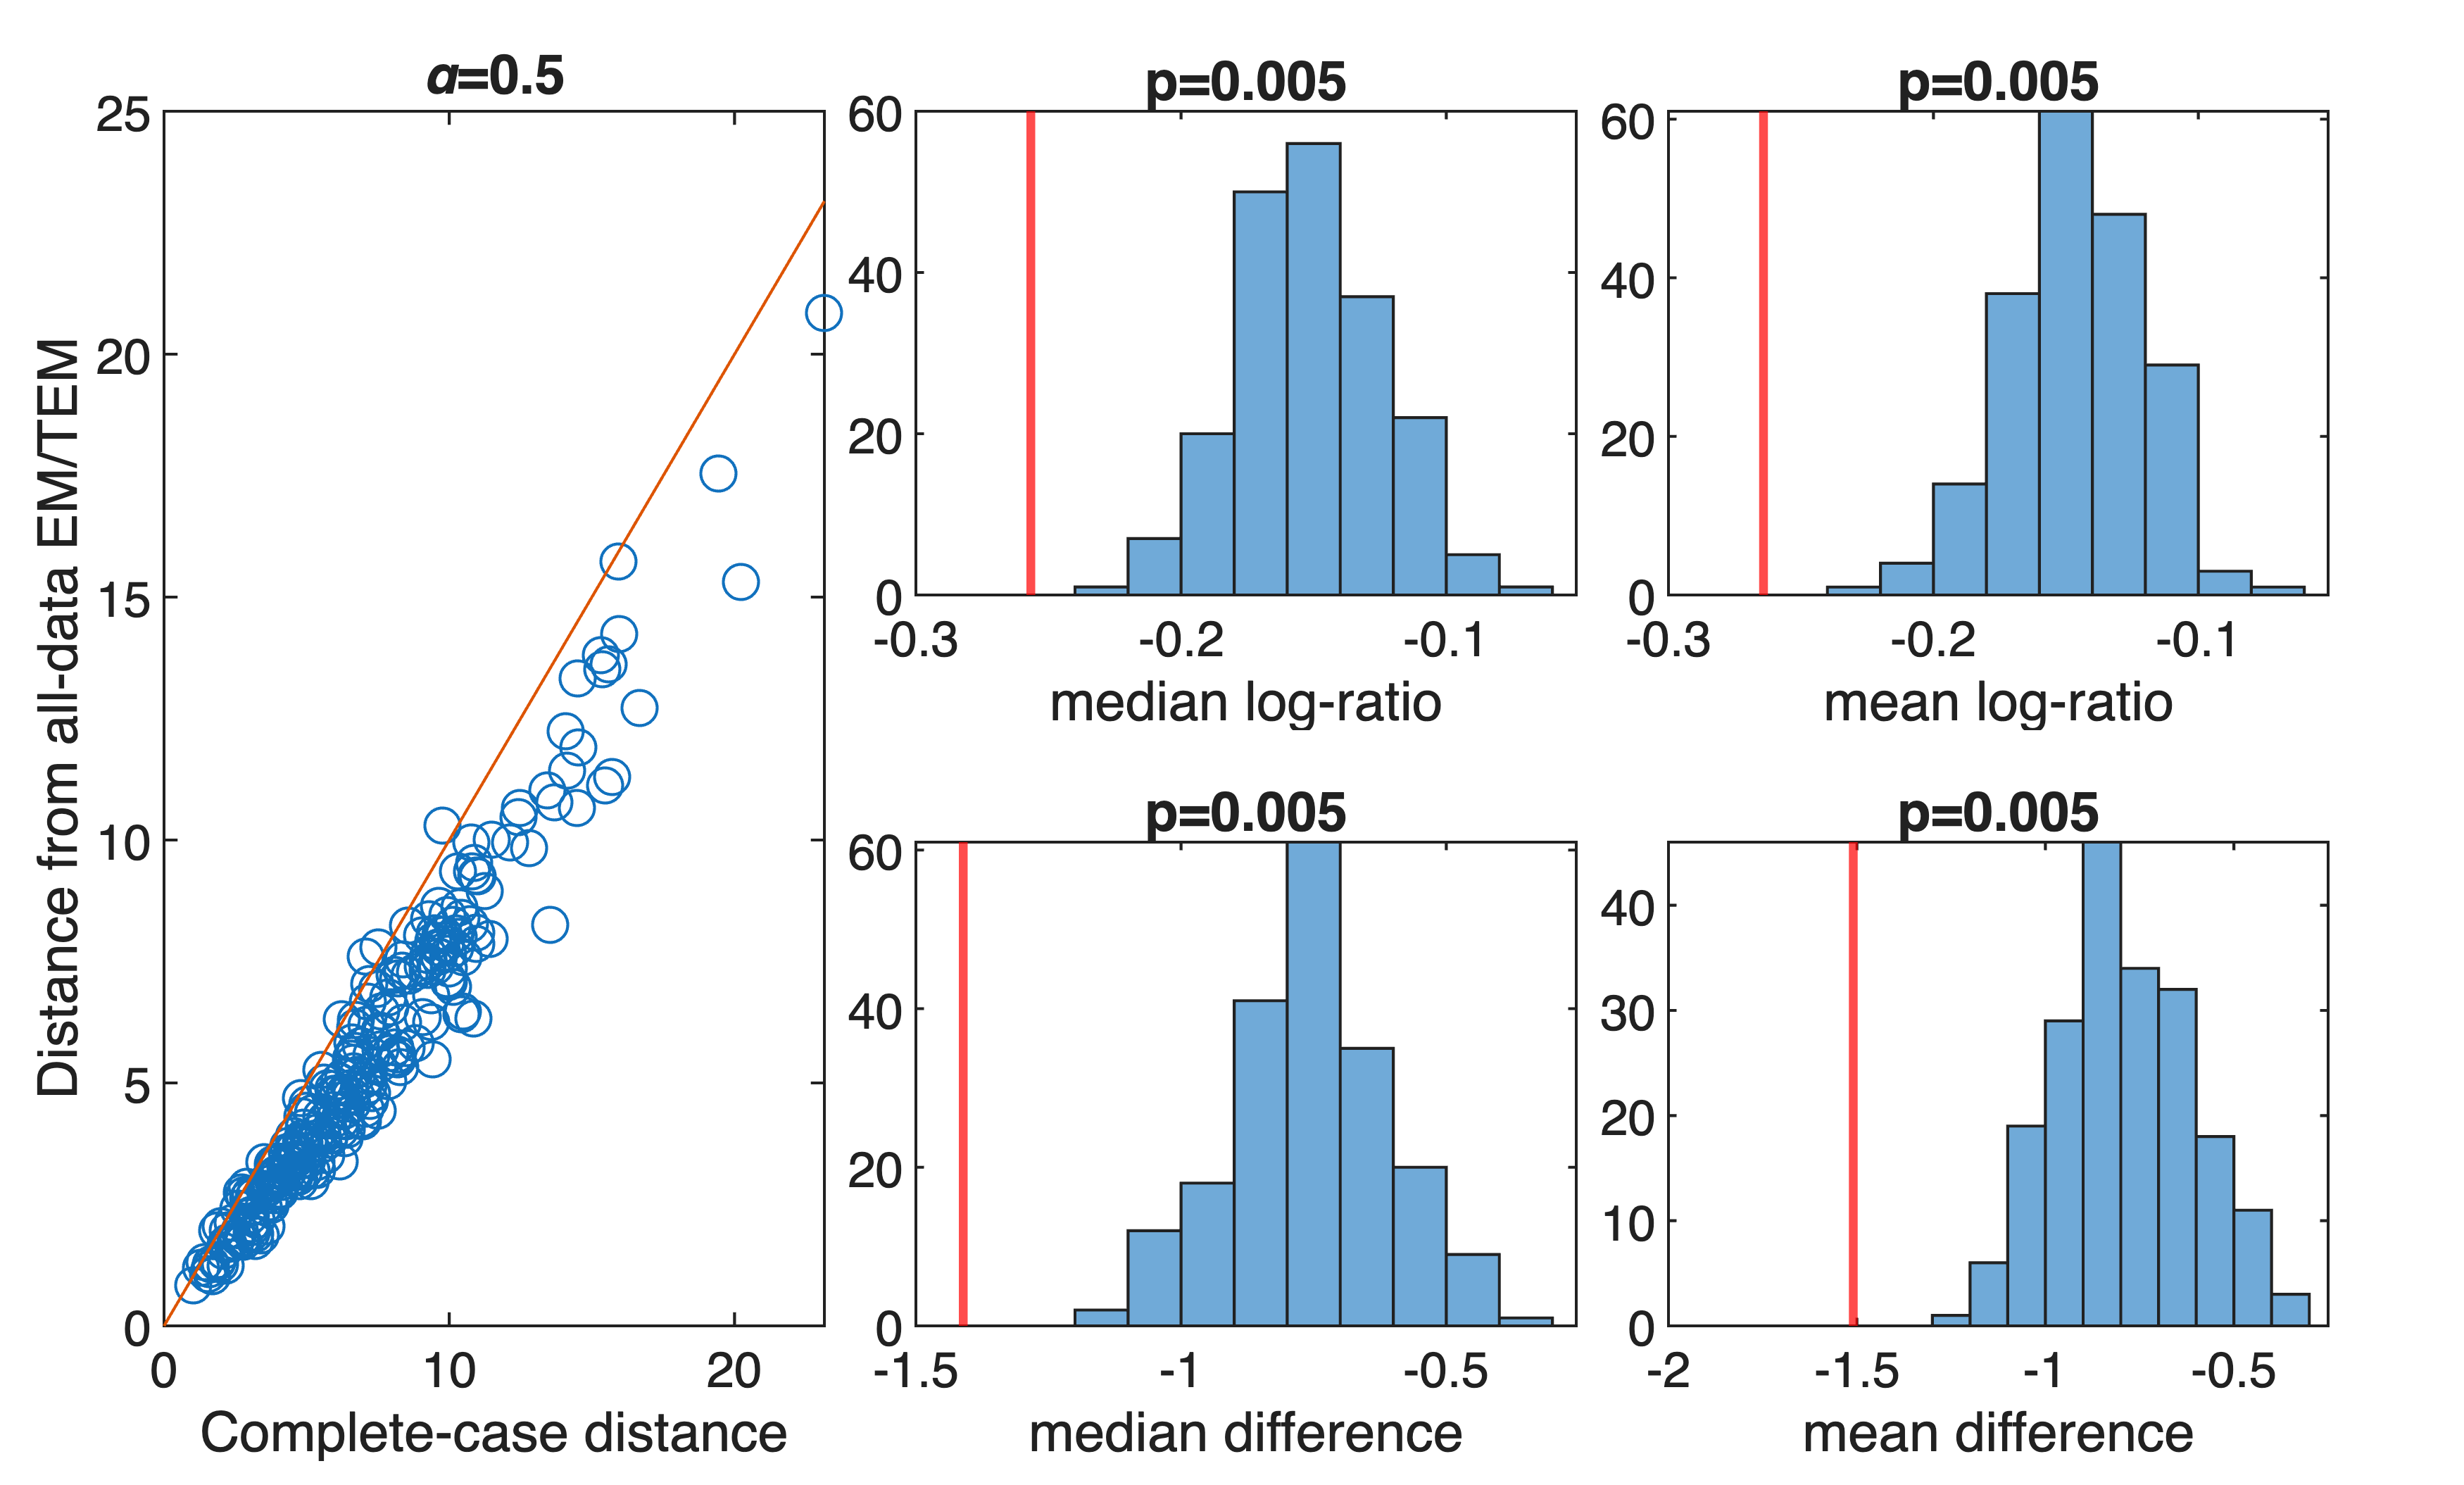

In [21]:
out = mdMCARtest(X2, 'alpha', 0.5,'method', 'pri', ...
    'nsimul', 199, 'plots', true);

In [22]:
disp(out.pvalue)

    0.0050    0.0050    0.0050    0.0050

In [23]:
disp(out.Tobs)

   -0.2566   -0.2641   -1.4109   -1.5099

In [24]:
disp(out.ciBoot)

   -0.2025   -0.1996   -1.0584   -1.1269
   -0.0961   -0.1006   -0.4568   -0.4360

In [25]:


if prin == true
    exportgraphics(gcf,'figs/testMCARpval.pdf')
end